In [16]:
from skimage import io, measure
import numpy as np
from cell_paint_seg.utils import (
    get_id_to_path,
    get_id_from_name_96,
    check_valid_labels,
    label_celltype,
    threat_score
)
from cell_paint_seg.image_io import read_seg
from tqdm.notebook import tqdm
import napari
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
channels = ["ER", "DNA", "Mito", "Actin", "RNA", "Golgi/membrane"]

# Save rgb

In [ ]:
path_r = "/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/og/Experiment4_DB_AD_unmixed_zprojection_s144c4.tif"
path_g = "/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/og/Experiment4_DB_AD_unmixed_zprojection_s144c5.tif"
path_b = "/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/og/Experiment4_DB_AD_unmixed_zprojection_s144c2.tif"

img_r = io.imread(path_r)
img_g = io.imread(path_g)
img_b = io.imread(path_b)

img_r = np.amax(img_r, -1)
img_g = np.amax(img_g, -1)
img_b = np.amax(img_b, -1)

img_rgb = np.stack([img_r, img_g, img_b], axis=-1)
#io.imsave("/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/3channel/e4_s144.tif", img_rgb)


# Clean up labels

In [58]:
dir_seg = (
    "/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/3channel"
)

factor = 1 # 0.6

id_to_path_seg = get_id_to_path(dir_seg, tag=".png", id_from_name_nchar=7)

for id, paths in id_to_path_seg.items():
    for path in paths:
        if "nuc" in str(path):
            seg_nuc = io.imread(path)
        elif "soma" in str(path):
            seg_soma = io.imread(path)
        elif "cell" in str(path):
            seg_cell = io.imread(path)

    print("Separating components...")
    for comp, seg in zip(["Nuc", "Soma", "Cell"], [seg_nuc, seg_soma, seg_cell]):
        new_label = np.amax(seg) + 1
        for label in np.unique(seg):
            # background
            if label == 0:
                continue

            lbl = measure.label(seg == label)
            if not np.amax(lbl) == 1:
                regprops = measure.regionprops(lbl)
                print(
                    f"{comp} {label} has {np.amax(lbl)} disconnected components - renaming {[np.multiply(props.centroid, factor) for props in regprops]}..."
                )
                for props in regprops[1:]:
                    mask = lbl == props["label"]
                    seg[mask] = new_label
                    new_label += 1

    print("Matching somas to nuclei...")
    soma_to_nuc = {}
    for nuc_label in tqdm(np.unique(seg_nuc)):
        if nuc_label == 0:
            continue
        found = False
        for soma_label in np.unique(seg_soma):
            if soma_label == 0:
                continue
            recall = np.sum((seg_nuc == nuc_label) & (seg_soma == soma_label)) / np.sum(
                (seg_nuc == nuc_label)
            )

            if recall > 0.8:
                assert soma_label not in soma_to_nuc.keys()
                soma_to_nuc[soma_label] = nuc_label
                found = True
        if not found:
            wher = np.where(seg_nuc == nuc_label)
            print(
                f"nuc {nuc_label} not found in soma {(wher[0][0]*factor, wher[1][0]*factor)}"
            )
    
    seg_soma_relabel = np.zeros_like(seg_soma)
    for soma_label, nuc_label in soma_to_nuc.items():
        seg_soma_relabel[seg_soma == soma_label] = nuc_label
    seg_soma = seg_soma_relabel

    print("Matching somas to cells...")
    cell_to_soma = {}
    for soma_label in tqdm(np.unique(seg_soma)):
        if soma_label == 0:
            continue
        found = False
        for cell_label in np.unique(seg_cell):
            if cell_label == 0:
                continue
            recall = np.sum(
                (seg_soma == soma_label) & (seg_cell == cell_label)
            ) / np.sum((seg_soma == soma_label))

            if recall > 0.8:
                if cell_label in cell_to_soma.keys():
                    print(f"cell {cell_label} already matched to soma")
                # assert cell_label not in cell_to_soma.keys()
                cell_to_soma[cell_label] = soma_label
                found = True

        if not found:
            wher = np.where(seg_soma == soma_label)
            print(
                f"soma {soma_label} not found in cells {(wher[0][0]*factor, wher[1][0]*factor)}"
            )

    seg_cell_relabel = np.zeros_like(seg_cell)
    for cell_label, soma_label in cell_to_soma.items():
        seg_cell_relabel[seg_cell == cell_label] = soma_label
    seg_cell = seg_cell_relabel

    print("Subsetting...")
    for label in np.unique(seg_nuc):
        if label == 0:
            continue
        seg_soma[seg_nuc == label] = label
        seg_cell[seg_soma == label] = label

    print("Relabelling consecutively...")
    seg_nuc_relabeled = np.zeros_like(seg_nuc)
    seg_soma_relabeled = np.zeros_like(seg_soma)
    seg_cell_relabeled = np.zeros_like(seg_cell)
    counter = 1
    for label in np.unique(seg_nuc):
        if label == 0:
            continue
        seg_nuc_relabeled[seg_nuc == label] = counter
        seg_soma_relabeled[seg_soma == label] = counter
        seg_cell_relabeled[seg_cell == label] = counter
        counter += 1

    
    seg_nuc = seg_nuc_relabeled.astype(np.int32)
    seg_soma = seg_soma_relabeled.astype(np.int32)
    seg_cell = seg_cell_relabeled.astype(np.int32)

    out_dir = paths[0].parent
    io.imsave(out_dir / f"{id}_seg_nuc_relabelled.png", seg_nuc)
    io.imsave(out_dir / f"{id}_seg_soma_relabelled.png", seg_soma)
    io.imsave(out_dir / f"{id}_seg_cell_relabelled.png", seg_cell)

Separating components...
Matching somas to nuclei...


  0%|          | 0/242 [00:00<?, ?it/s]

Matching somas to cells...


  0%|          | 0/242 [00:00<?, ?it/s]

Subsetting...
Relabelling consecutively...


...

  0%|          | 0/151 [00:00<?, ?it/s]

Matching somas to cells...


  0%|          | 0/151 [00:00<?, ?it/s]

Subsetting...
Relabelling consecutively...


/var/folders/gy/jk_d3cx54vj18w9sm6x3sg_80000gn/T/ipykernel_21547/2381142023.py:122: UserWarning: /Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/3channel/e1_s036_seg_nuc_relabelled.png is a low contrast image
  io.imsave(out_dir / f"{id}_seg_nuc_relabelled.png", seg_nuc)
/var/folders/gy/jk_d3cx54vj18w9sm6x3sg_80000gn/T/ipykernel_21547/2381142023.py:123: UserWarning: /Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/3channel/e1_s036_seg_soma_relabelled.png is a low contrast image
  io.imsave(out_dir / f"{id}_seg_soma_relabelled.png", seg_soma)
/var/folders/gy/jk_d3cx54vj18w9sm6x3sg_80000gn/T/ipykernel_21547/2381142023.py:124: UserWarning: /Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/3channel/e1_s036_seg_cell_relabelled.png is a low contrast image
  io.imsave(out_dir / f"{id}_seg_cell_relabelled.png", seg_cell)


In [48]:
viewer = napari.Viewer()
viewer.add_labels(seg_nuc, name=f"{id}: nuc")
viewer.add_labels(seg_soma, name=f"{id}: soma")
viewer.add_labels(seg_cell, name=f"{id}: cell")

<Labels layer 'e1_s036: cell' at 0x182546c70>

# Evaulate alg segmentation

In [13]:
def unq_lbl(seg):
    # convert rgb to grayscale
    if seg.ndim == 3:
        seg_new = np.zeros(seg.shape[:2], dtype=np.uint32)
        seg_new = seg[:,:,0]*256**2 + seg[:,:,1]*256 + seg[:,:,2]
        seg = seg_new

    # separate connected components
    seg_new = np.zeros_like(seg)
    counter = 1
    for lbl in np.unique(seg[seg > 0]):
        label = measure.label(seg == lbl)
        for new_lbl in np.unique(label):
            if new_lbl == 0:
                continue
            seg_new[label == new_lbl] = counter
            counter += 1
    return seg_new

def id_from_name(name):
    return name[:10]


In [78]:
path_tommy = "/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/release/annotations"
path_alg = "/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/images_for_algs"

algs = ["cyto3", "cyto2", "stardist", "cellprof", "mediar", "sam", "hover"]
#algs = ["hover"]

tag_to_name = {"nuc": "Nuclei", "soma": "Somas", "cell": "Cells"}

data_val = []
data_metric = []
data_iou = []
data_comp = []
data_method = []
data_finetune = []

data_semantic_iou = []
data_semantic_comp = []
data_semantic_matchup = []



for alg in tqdm(algs, desc="annotator pairs..."):
    for compartment in tqdm(list(tag_to_name.keys()), leave=False, desc="compartments..."):
        id_to_paths_gt = get_id_to_path(path_tommy, id_from_name, tag=f"{compartment}_ann1_scratch")
        id_to_paths_alg = get_id_to_path(path_alg, id_from_name, tag=f"{alg}_{compartment}")

        for iou_thresh in tqdm(np.arange(0.5, 1.0, 0.1), leave=False, desc="IoU thresholds..."):
            tp_total = 0
            fp_total = 0
            fn_total = 0
            for id, path in tqdm(id_to_paths_gt.items(), leave=False, desc="ids..."):
                if id != "e1_wC10_f3": #e3_wB5_f3_, e4_wF9_f3_, e1_wC10_f3
                    continue

                try:
                    seg_1 = read_seg(path)
                    seg_2 = read_seg(id_to_paths_alg[id])
                    if alg == "cyto2" or alg == "cellprof":
                        seg_2 = unq_lbl(seg_2)
                    
                    tps, fps, fns = threat_score(seg_1, seg_2, iou_thresh)
                    tp_total += tps
                    fp_total += fps
                    fn_total += fns
                except Exception as e:
                    print(f"Exception: {e} under {alg}, {compartment}")
                    pass


            if tp_total + fp_total == 0:
                prec = 1
            else:
                prec = tp_total / (tp_total + fp_total)
            rec = tp_total / (tp_total + fn_total)

            if prec + rec == 0:
                f1 = 0
            else:
                f1 = 2 * (prec * rec) / (prec + rec)
            metrics, vals = ["F1 Score"], [f1]

            for metric, val in zip(metrics, vals):
                data_iou.append(iou_thresh)
                data_metric.append(metric)
                data_val.append(val)
                data_comp.append(tag_to_name[compartment])
                data_method.append(alg)

df = pd.DataFrame({"IoU Threshold": data_iou, "F1 Score": data_val, "Metric": data_metric, "Compartment": data_comp, "Comparison": data_method})


annotator pairs...:   0%|          | 0/7 [00:00<?, ?it/s]

compartments...:   0%|          | 0/3 [00:00<?, ?it/s]

IoU thresholds...:   0%|          | 0/5 [00:00<?, ?it/s]

ids...:   0%|          | 0/3 [00:00<?, ?it/s]

ids...:   0%|          | 0/3 [00:00<?, ?it/s]

...

ids...:   0%|          | 0/3 [00:00<?, ?it/s]

ids...:   0%|          | 0/3 [00:00<?, ?it/s]

ids...:   0%|          | 0/3 [00:00<?, ?it/s]

ids...:   0%|          | 0/3 [00:00<?, ?it/s]

ids...:   0%|          | 0/3 [00:00<?, ?it/s]

(0.0, 1.0)

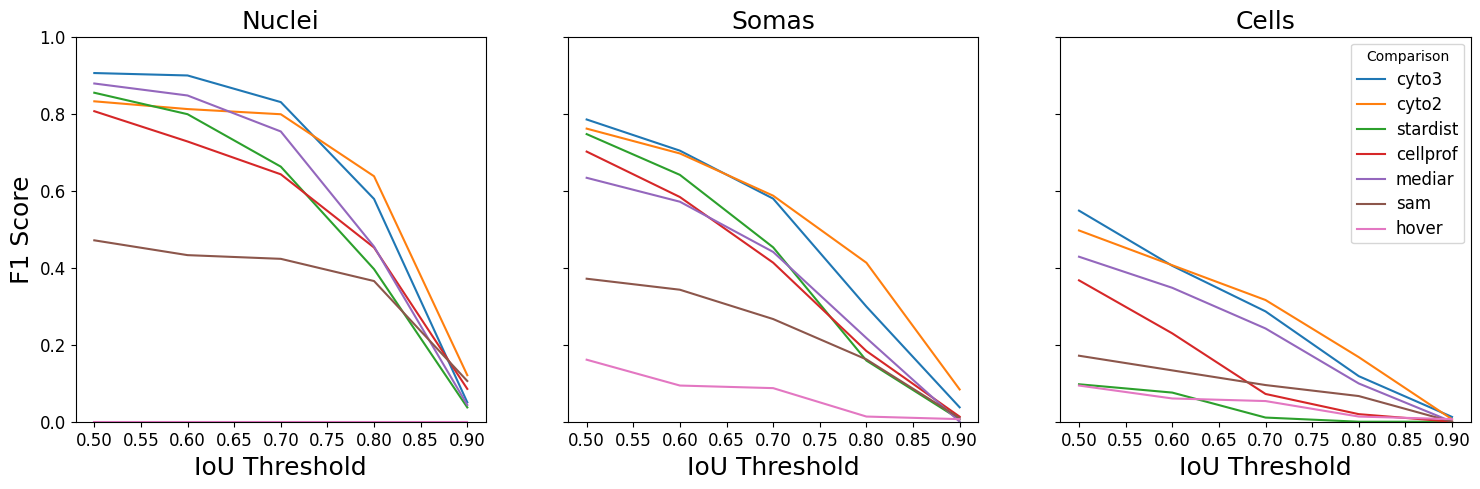

In [81]:
f, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for compartment, ax in zip(["Nuclei", "Somas", "Cells"], axs):
    sns.lineplot(data=df[df["Compartment"] == compartment], ax=ax, x="IoU Threshold", y="F1 Score", hue="Comparison")#, style="Finetuned")
    ax.set_title(compartment)

# axs[0].set_title("Nuclei Instance Agreement")
# axs[1].set_title("b) Somas Instance Agreement")
# axs[2].set_title("c) Cell Instance Agreement")


for ax in axs:
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label]):
        item.set_fontsize(18)

    for item in (ax.get_xticklabels() + ax.get_yticklabels() + ax.get_legend().get_texts()):
        item.set_fontsize(12)

# remove legend except for last panel
for ax in axs[:-1]:
    ax.get_legend().remove()
    
plt.ylim(0, 1.0)
# #plt.suptitle("Cellpose Cyto3 Performance")
# plt.savefig("/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/figures/alg_results/performance.svg")

In [54]:

folder = Path("/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/hover")


from scipy.io import loadmat
# for every mat file in folder, load it, and save it as a tif
for file in folder.glob("*.mat"):
    print(file)
    seg = loadmat(file)['inst_map']
    print(seg.dtype)

    if "dna" in file.stem:
    
        new_name = file.stem[:10] + "_hover_nuc"
        new_file = file.parent / f"{new_name}.tif"
        io.imsave(new_file, seg)
    else:
        new_name = file.stem[:10] + "_hover_soma"
        new_file = file.parent / f"{new_name}.tif"
        io.imsave(new_file, seg)
        #replace "soma" with "cell" and save that too
        new_name = file.stem[:10] + "_hover_cell"
        new_file = file.parent / f"{new_name}.tif"
        io.imsave(new_file, seg)
        



/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/hover/e3_wB5_f3_dna_3c.mat
int32
/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/hover/e4_wF9_f3.mat
int32
/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/hover/e4_wF9_f3_dna_3c.mat
int32
/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/hover/e1_wC10_f3.mat
int32
/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/hover/e1_wC10_f3_dna_3c.mat
int32
/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/hover/e3_wB5_f3.mat
int32


/var/folders/gy/jk_d3cx54vj18w9sm6x3sg_80000gn/T/ipykernel_78223/1104195999.py:15: UserWarning: /Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/hover/e3_wB5_f3__hover_nuc.tif is a low contrast image
  io.imsave(new_file, seg)
/var/folders/gy/jk_d3cx54vj18w9sm6x3sg_80000gn/T/ipykernel_78223/1104195999.py:19: UserWarning: /Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/hover/e4_wF9_f3_hover_soma.tif is a low contrast image
  io.imsave(new_file, seg)
/var/folders/gy/jk_d3cx54vj18w9sm6x3sg_80000gn/T/ipykernel_78223/1104195999.py:23: UserWarning: /Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/hover/e4_wF9_f3_hover_cell.tif is a low contrast image
  io.imsave(new_file, seg)
/var/folders/gy/jk_d3cx54vj18w9sm6x3sg_80000gn/T/ipykernel_78223/1104195999.py:15: UserWarning: /Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/hover/e4_wF9_f3__hover_nuc.tif is a low contrast image
  io.im

In [80]:
from skimage import io 

paths = [
    "/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/release/annotations/e1_wB10_f2_cell_ann1.tif",
    "/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/release/annotations/e2_wG2_f2_cell_ann1.tif",
    "/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/release/annotations/e4_wD2_f2_cell_ann1.tif",
    "/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/release/annotations/e2_wD11_f2_cell_ann1.tif",
    "/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/release/annotations/e3_wD11_f3_cell_ann1.tif",
    "/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/release/annotations/e4_wF9_f3_nuc_ann1_scratch.png",
    "/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/release/annotations/e3_wB5_f3_nuc_ann1_scratch.png",
    "/Users/thomasathey/Documents/shavit-lab/fraenkel/papers/miccai/rebuttal/data/release/annotations/e1_wC10_f3_soma_ann1_scratch.png"
]

for path in paths:
    seg = io.imread(path)
    print(len(np.unique(seg)))

263
248
404
851
532
242
336
151


In [60]:
263+248+404

915